[ 0.59256524  8.35012158  1.52251315 11.14409651]


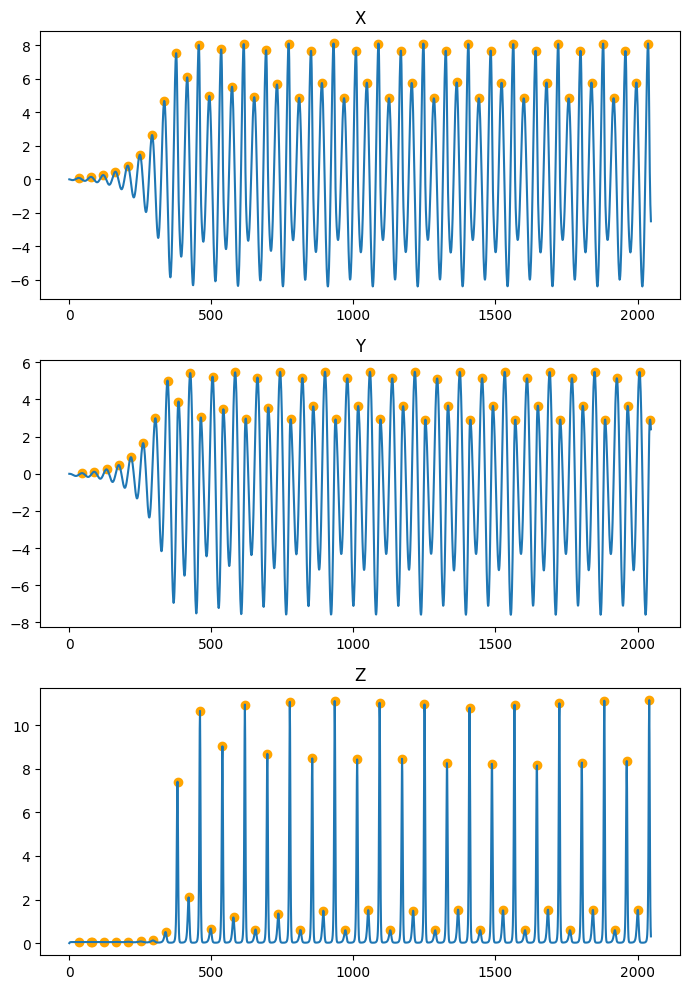

In [1]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
from scipy.signal import find_peaks
a=0.2
b=0.2
c=4
# Rassel attractor
def system(t,x):
    x,y,z = x
    return [
        -y-z,
        x+a*y,
        b+z*(x-c)
    ]

t_eval = np.linspace(0,1,2048)*300
states = solve_ivp(system,(t_eval.min(),t_eval.max()),[0,0,0],t_eval=t_eval).y
x,y,z=states
x_peaks = find_peaks(x)[0]
y_peaks = find_peaks(y)[0]
z_peaks = find_peaks(z)[0]

print(z[z_peaks[z_peaks>1900]])

plt.figure(figsize=(7,10))
plt.subplot(3,1,1)
plt.plot(x)
plt.scatter(x_peaks,x[x_peaks],c='orange')
plt.title("X")

plt.subplot(3,1,2)
plt.plot(y)
plt.scatter(y_peaks,y[y_peaks],c='orange')
plt.title("Y")

plt.subplot(3,1,3)
plt.plot(z)
plt.scatter(z_peaks,z[z_peaks],c='orange')
plt.title("Z")

plt.tight_layout()

In [2]:
import plotly.graph_objects as go

x, y, z = states

# Create an interactive 3D plot
fig = go.Figure(data=[go.Scatter3d(
    x=x, y=y, z=z,
    mode='lines',
    line=dict(
        color=t_eval,      # Color path by time progress
        colorscale='Viridis', 
        width=4
    ),
    name='Rossler Path'
)])

fig.update_layout(
    title='Interactive Rossler Attractor Investigation',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        bgcolor='rgb(20, 20, 20)' # Dark background for better visibility
    ),
    template='plotly_dark',
    margin=dict(l=0, r=0, b=0, t=40),
    width=700,
    height=700
)

fig.show()


In [3]:
def get_system_peaks(a=0.2,b=0.2,c=3,t_max=400,resolution=2048):
    t_eval = np.linspace(0,1,resolution)*t_max
    # Rassel attractor
    def system(t,x):
        x,y,z = x
        return [
            -y-z,
            x+a*y,
            b+z*(x-c)
        ]
    
    states = solve_ivp(system,(t_eval.min(),t_eval.max()),[1,1,1],t_eval=t_eval).y
    x,y,z=states
    
    z_peaks = find_peaks(z)[0]
    
    peaks=z[z_peaks[z_peaks>resolution-200]]
    
    return peaks


In [4]:
from joblib import Parallel,delayed
c_values = np.linspace(2, 15, 300)

peaks = Parallel(n_jobs=-1)([delayed(get_system_peaks)(0.2,0.2,c) for c in c_values])

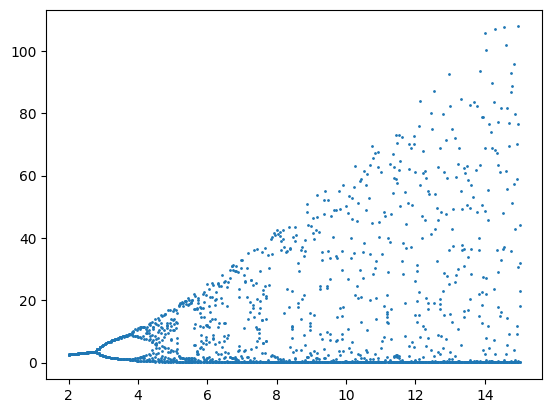

In [5]:
X_render = []
y_render = []
for cv,p in enumerate(peaks):
    X_render+=[c_values[cv]]*len(p)
    y_render+=p.tolist()

plt.scatter(X_render,y_render,s=1)

In [6]:
# Menge Sponge
# имеет фрактальную размерность ln(20)/ln(3)
import math

print("Menge Sponge dimensions",math.log(20)/math.log(3))

Menge Sponge dimensions 2.7268330278608417


In [133]:
import numpy as np
from scipy.integrate import solve_ivp
import plotly.graph_objects as go

# Параметры системы Лоренца
sigma = 10.0
rho = 28.0
beta = 8/3

def lorenz_system(t, state):
    x, y, z = state
    return [
        sigma * (y - x),
        x * (rho - z) - y,
        x * y - beta * z
    ]

# Настройка времени и решение (увеличим время до 80 для наглядности структуры)
t_eval = np.linspace(0, 80, 4096)
initial_state = [1.0, 1.0, 1.0]

sol = solve_ivp(lorenz_system, (t_eval.min(), t_eval.max()), initial_state, t_eval=t_eval)
x, y, z = sol.y

# Создание интерактивного 3D графика
fig = go.Figure(data=[go.Scatter3d(
    x=x, y=y, z=z,
    mode='lines',
    line=dict(
        color=t_eval,      # Раскраска по времени
        colorscale='Inferno', 
        width=3
    ),
    name='Lorenz Attractor'
)])

fig.update_layout(
    title='Interactive Lorenz Attractor (Butterfly Effect)',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        bgcolor='rgb(15, 15, 15)'
    ),
    template='plotly_dark',
    margin=dict(l=0, r=0, b=0, t=40),
    width=800,
    height=800
)

fig.show()


[8]


Text(0.5, 1.0, 'Lags mutual information')

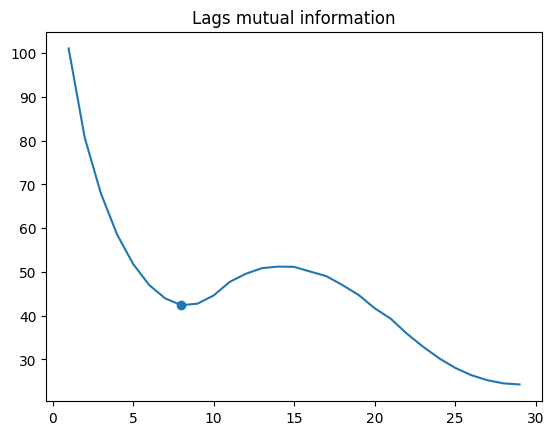

In [161]:
import scipy

def mutual_information(data, delay, n_bins):
    """
    Calculate the mutual information for a given delay using histograms.
    """
    # Prepare delayed data
    delayed_data = data[delay:]
    original_data = data[:-delay]

    # Compute histograms
    p_x, bin_edges = np.histogram(original_data, bins=n_bins, density=True)
    p_y, _ = np.histogram(delayed_data, bins=bin_edges, density=True)
    p_xy, _, _ = np.histogram2d(original_data, delayed_data, bins=bin_edges, density=True)

    # Calculate mutual information
    mutual_info = 0
    for i in range(n_bins):
        for j in range(n_bins):
            if p_xy[i, j] > 0 and p_x[i] > 0 and p_y[j] > 0:
                mutual_info += p_xy[i, j] * np.log(p_xy[i, j] / (p_x[i] * p_y[j]))

    return mutual_info

X = np.stack([x,y,z],-1)
X_norm = (X-np.mean(X,0,keepdims=True))/np.std(X,0,keepdims=True)
x_norm=X_norm[:,[0]]

lags = range(1,30)
MI = np.array([mutual_information(x_norm[:,0],l,32) for l in lags])
peaks = scipy.signal.find_peaks(-MI,distance=15)[0]
print(peaks+1)
plt.plot(lags,MI)
plt.scatter(peaks+1,MI[peaks])
plt.title("Lags mutual information")

[3]


Text(0.5, 1.0, 'Time-series dimensions of false nearest neighbors')

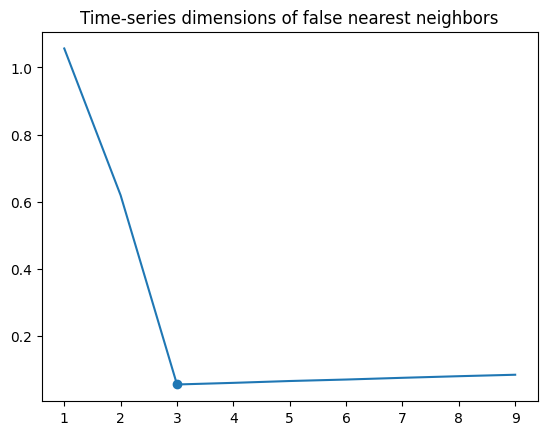

In [163]:
# X_norm of shape [seqlen] is one-dimensional timeseries
from sklearn.neighbors import NearestNeighbors

X = X_norm.flatten()
embed = lambda s, d: s[np.arange(len(s)-(d-1))[:, None] + np.arange(d)]
fnn = []
lags = range(1, 10)
for d in lags:
    e1, e2 = embed(X, d), embed(X, d+1)
    e1 = e1[:len(e2)]
    dist, idx = NearestNeighbors(n_neighbors=2).fit(e1).kneighbors(e1)
    fnn.append(np.mean(np.linalg.norm(e2 - e2[idx[:, 1]], axis=1)))
fnn = np.array(fnn)
peaks = scipy.signal.find_peaks(-fnn,distance=15)[0]
print(peaks+1)
plt.plot(lags,fnn)
plt.scatter(peaks+1,fnn[peaks])
plt.title("Time-series dimensions of false nearest neighbors")

In [177]:
def get_lagged(X : np.ndarray,lags = [1]):
    """
    Accepts X in shape [SEQLEN,DIM]
    Returns [B,lags,DIM]
    """
    max_lag=max(lags)
    lags_list=[]
    current = X[max_lag:]
    for l in lags:
        if l==0:
            lags_list.append(current)
        elif l>0:
            lags_list.append(X[max_lag-l:-l])
    return np.stack(lags_list,1)

taken_emb = get_lagged(x_norm,lags=range(0,9))
taken_emb=taken_emb.reshape(taken_emb.shape[0],-1)

y = X_norm[-len(taken_emb):]


In [180]:
# Теперь делаем регрессию y по taken_emb
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split


taken_train,taken_test,y_train,y_test = train_test_split(taken_emb,y,test_size=0.1)

rfr_y = RandomForestRegressor()
rfr_y.fit(taken_train,y_train[:,1])
print("y score",rfr_y.score(taken_test,y_test[:,1]))

rfr_z = RandomForestRegressor()
rfr_z.fit(taken_train,y_train[:,2])
print("z score",rfr_z.score(taken_test,y_test[:,2]))

y score 0.999093424607715
z score 0.9919331501482378


In [ ]:
# Используя первую переменную X и вложения такена делаем регрессию остальных параметров
# состояния системы
y_rec = rfr_y.predict(taken_emb)
z_rec = rfr_z.predict(taken_emb)


# Создание интерактивного 3D графика
fig = go.Figure(data=[go.Scatter3d(
    x=y[:,0], y=y_rec, z=z_rec,
    mode='lines',
    line=dict(
        color=t_eval,      # Раскраска по времени
        colorscale='Inferno', 
        width=3
    ),
    name='Lorenz Attractor'
)])

fig.update_layout(
    title='Reconstruction of Lorenz Attractor on Taken Embeddings',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        bgcolor='rgb(15, 15, 15)'
    ),
    template='plotly_dark',
    margin=dict(l=0, r=0, b=0, t=40),
    width=800,
    height=800
)

fig.show()


In [271]:
from reservoir_computing.reservoir import Reservoir

res = Reservoir(
    n_internal_units=40,spectral_radius=0.95,connectivity=0.2,input_scaling=0.1)
cycled = np.concatenate([x_norm]*4,axis=0)
states = res.get_states(cycled[None,:])[0][-len(x_norm):]
states-=states.mean()
states/=states.std()

In [272]:
from sklearn.decomposition import PCA


pca = PCA(n_components=3)
x,y,z = pca.fit_transform(states).T

# Создание интерактивного 3D графика
fig = go.Figure(data=[go.Scatter3d(
    x=x, y=y_rec, z=z,
    mode='lines',
    line=dict(
        color=t_eval,      # Раскраска по времени
        colorscale='Inferno', 
        width=3
    ),
    name='Lorenz Attractor'
)])

fig.update_layout(
    title='Reservoir states visualization',
    scene=dict(
        xaxis_title='X',
        yaxis_title='Y',
        zaxis_title='Z',
        bgcolor='rgb(15, 15, 15)'
    ),
    template='plotly_dark',
    margin=dict(l=0, r=0, b=0, t=40),
    width=800,
    height=800
)

fig.show()